## Paso 3: Exploratory Data Analysis (EDA) - FD001
Objetivos del MVP:
1. Verificar la carga de datos sin errores usando nuestro modulo estandarizado.
2. Encontrar y descartar sensores con varianza 0 (ruido inútil en FD001).
3. Visualizar el ciclo vital típico de un motor para entender cómo luce visualmente nuestro **Target de 30 ciclos**.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Asegurar que la carpeta src sea visible
sys.path.append('..')
from src.data import load_cmapss_data

# Cargar train usando un código productivo (no re-implementarlo aquí)
train_df = load_cmapss_data('train_FD001.txt')
print(f"Dimensiones Train: {train_df.shape}")
train_df.head()

Dimensiones Train: (20631, 26)


,unit_id,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1. Eliminar variables sin varianza
En FD001 solo hay UN régimen operativo. Por eso, variables como Mach Number o ciertas presiones constantes no aportan ninguna señal de degradación predictiva, solo ruido y costo computacional. Calcularemos la desviación típica y descartaremos las invariantes.

In [2]:
std_dev = train_df.std()
zero_variance_cols = std_dev[std_dev < 1e-4].index.tolist()

print(f"Columnas constantes (ruido inútil):\n{zero_variance_cols}\n")

useful_cols = [col for col in train_df.columns if col not in zero_variance_cols]
print(f"Nos quedamos con {len(useful_cols)} columnas útiles frente a las {len(train_df.columns)} iniciales.")

Columnas constantes (ruido inútil):
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Nos quedamos con 19 columnas útiles frente a las 26 iniciales.


### 2. Visualizar Degradación en un solo Motor
Para entender el problema desde el negocio (Mantenimiento Predictivo), no importa graficar las 20 variables. Solo necesitamos entender que los valores de un sensor se degradan según avanza el ciclo (`time_cycle`). Veremos el sensor 2 para el motor (`unit_id`) número 1.

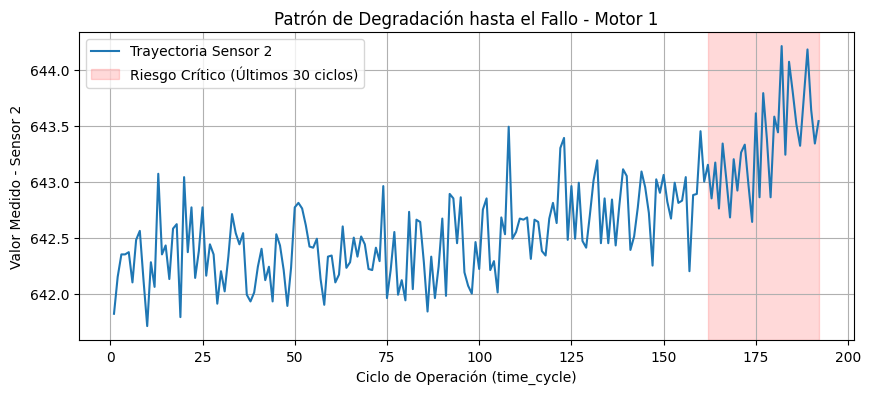

In [3]:
unit_id_plot = 1
engine_data = train_df[train_df['unit_id'] == unit_id_plot]

plt.figure(figsize=(10, 4))
plt.plot(engine_data['time_cycle'], engine_data['sensor_2'], label='Trayectoria Sensor 2')

# Sombramos la Zona Crítica (El Target del MVP)
target_window = 30
max_cycle = engine_data['time_cycle'].max()
plt.axvspan(
    max_cycle - target_window, 
    max_cycle, 
    color='red', alpha=0.15, label=f'Riesgo Crítico (Últimos {target_window} ciclos)'
)

plt.xlabel('Ciclo de Operación (time_cycle)')
plt.ylabel('Valor Medido - Sensor 2')
plt.title(f'Patrón de Degradación hasta el Fallo - Motor {unit_id_plot}')
plt.legend()
plt.grid(True)
plt.show()